# 1qb-DB on the Novera chip — deterministic benchmark of the optimized X($\pi$)

Same protocol as `proposals/1qb-DB/` (`dblib.py`, unchanged in method); only the device
moves. `dblib.py` was extended (N3, additive, mirroring `_gatelib`'s own N1 `device=`
parameter) so `load_arms` and every `db: DBLab`-taking function can be pointed at a
non-default device instead of reading the package default -- see the N3 dev log for the
before/after check that `proposals/1qb-DB/notebook.ipynb` (default device) is unaffected.

Figures follow `proposals/1qb-DB/README.md` §3's "Figures" list (5 figures there; this
notebook shows 4 of the 5 the README calls out explicitly -- Fig.3 ($P_0(n)$), Fig.1
(played waveforms), Fig.2 (error curves, both channels), Fig.5 (signal vs. epsilon) --
plus the detuning-scan figure the earlier draft already had).

⚠️ Device check first, same as the other two notebooks.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parents[1]
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "proposals" / "_gatelib"))
sys.path.insert(0, str(repo_root / "proposals" / "1qb-DB"))

from curve_opt import recorder
import dblib as db

NOVERA = recorder.load_device(repo_root / "configs" / "device_novera.json")
assert NOVERA.anharmonicity == -0.19848, NOVERA.anharmonicity

lab = db.load_arms("Xpi_novera", dev=NOVERA)
assert lab.dev.anharmonicity == -0.19848, lab.dev.anharmonicity
assert all(a.device is NOVERA for a in lab.arms.values()), \
    "not every DBArm carries the Novera device"

print(f"gate {lab.gate_key}, arms {tuple(lab.arms)}, played grid N = {lab.n_play}, "
      f"T = {lab.dev.gate_time:g} ns")
print(f"T1 = {lab.dev.t1:g} ns   T2_echo = {lab.dev.t2_echo:g} ns   "
      f"decoherence floor = {lab.dev.decoherence_floor:.4e} per gate (waveform independent)")
print(f"cycles = {db.N_CYCLES}  ->  {2 * db.N_CYCLES} gates, "
      f"{2 * db.N_CYCLES * lab.dev.gate_time / 1e3:.2f} us elapsed")
print(f"T1 / elapsed = {lab.dev.t1 / (2 * db.N_CYCLES * lab.dev.gate_time):.2f}  "
      f"-- NOT rescaled from the default-device study's N_CYCLES=60 (there T1/elapsed "
      f"was ~10): T1 is shorter here (35 us vs the default device) and the sequence "
      f"length is deliberately left alone (README §5 point 3 / task brief), so the "
      f"envelope floor below is expected to be higher than in the X(pi) study, not a bug.")

<string>:12: UserWarning: leakage-resonant harmonic n* = 2*T*|alpha| = 19.848 != n_modes = 20: the C4 spectral zero no longer lands on a basis harmonic (device.GROUPS, _plan_full_cost.md 2.6). This is allowed -- it is a design choice, not an error -- but any C4 claim from this device needs the mismatch stated.


gate Xpi_novera, arms ('A', 'B', 'C', 'D', 'E', 'F'), played grid N = 120, T = 50 ns
T1 = 35000 ns   T2_echo = 41900 ns   decoherence floor = 6.3587e-04 per gate (waveform independent)
cycles = 60  ->  120 gates, 6.00 us elapsed
T1 / elapsed = 5.83  -- NOT rescaled from the default-device study's N_CYCLES=60 (there T1/elapsed was ~10): T1 is shorter here (35 us vs the default device) and the sequence length is deliberately left alone (README §5 point 3 / task brief), so the envelope floor below is expected to be higher than in the X(pi) study, not a bug.


## Fig. 1 — played waveforms

Fixed colours per quadrature (not per arm): $\Omega_x$ (drive) and $\Omega_y$
(DRAG/Stark correction) are different physical channels and must read the same way in
every panel (README §3, Fig. 1).

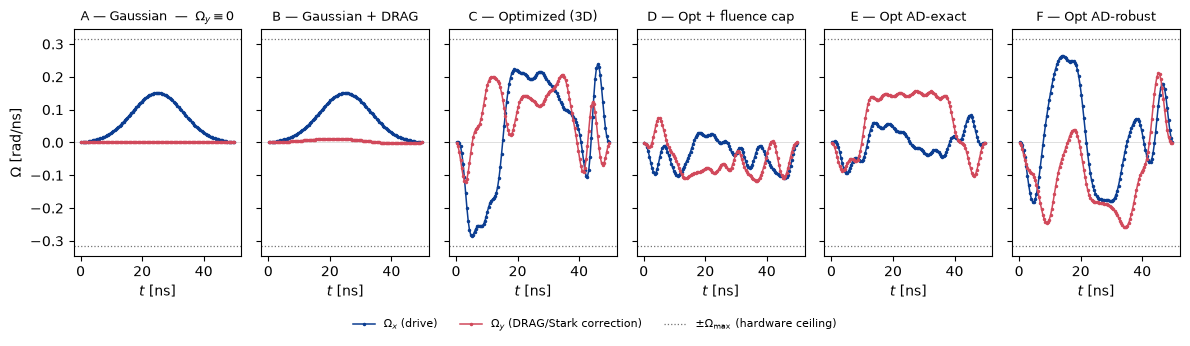

In [2]:
fig = db.plot_played_waveforms(lab)
plt.show()

## Calibration ($\epsilon=0$ reference) and axial closure

In [3]:
cals = db.print_calibration(lab)
print()
axial = db.print_axial_table(lab)

calibration knobs: frame_phase   (fitted once at delta_z = eps = 0, then frozen)
arm waveform               scale  d_cal[MHz]  virtual Z  rot.err before      after        1-F         P2  vz-phi_vz
-------------------------------------------------------------------------------------------------------------------
A   Gaussian             1.00000      0.0000    0.00000       1.738e-03  1.738e-03  1.745e-03  1.051e-05  -6.91e-11
B   Gaussian + DRAG      1.00000      0.0000    0.13526       7.459e-06  7.459e-06  7.462e-06  4.258e-09  -2.15e-04
C   Optimized (3D)       1.00000      0.0000   -0.13395       1.705e-07  1.705e-07  6.135e-05  6.407e-05   6.97e-04
D   Opt + fluence cap    1.00000      0.0000    2.53596       1.616e-08  1.616e-08  4.166e-06  1.038e-05   1.71e-03
E   Opt AD-exact         1.00000      0.0000    3.03076       1.500e-09  1.500e-09  2.397e-08  2.640e-08  -9.92e-05
F   Opt AD-robust        1.00000      0.0000   -2.61843       4.307e-09  4.307e-09  3.465e-07  9.125e-07  -

axial (echo-surviving) closure of both channels, at eps = 3% and delta_z/2pi = 0.1 MHz
arm waveform               |R_amp|   |n.R_amp|   angle/cyc  |R_z| [ns]  |n.R_z| [ns]   angle/cyc    Z/amp
---------------------------------------------------------------------------------------------------------
A   Gaussian                3.1416      3.1416  1.8850e-01     17.2432        0.0000  0.0000e+00     0.00
B   Gaussian + DRAG         3.1532      3.1299  1.8779e-01     17.1496        0.1547  1.9443e-04     0.00
C   Optimized (3D)          4.9857      0.6948  4.1690e-02      2.8242        2.1723  2.7298e-03     0.07
D   Opt + fluence cap       3.0077      0.3336  2.0015e-02     25.9023       23.4004  2.9406e-02     1.47
E   Opt AD-exact            2.9969      0.8214  4.9285e-02      7.9258        7.3003  9.1738e-03     0.19
F   Opt AD-robust           0.2305      0.0587  3.5197e-03      7.9941        7.8588  9.8757e-03     2.81
Z/amp > 1 means the DB trace is reporting the quasi-static Z chan

## Fig. 2 — error curves, both channels

★ Both the amplitude and the dephasing (quasi-static $Z$) error curve -- README §3 point 2
is explicit that the second is not optional. Each curve starts at the origin ($\circ$) and
ends at $\mathbf R(T)$ ($\blacksquare$); the gap between the two markers is the closure.

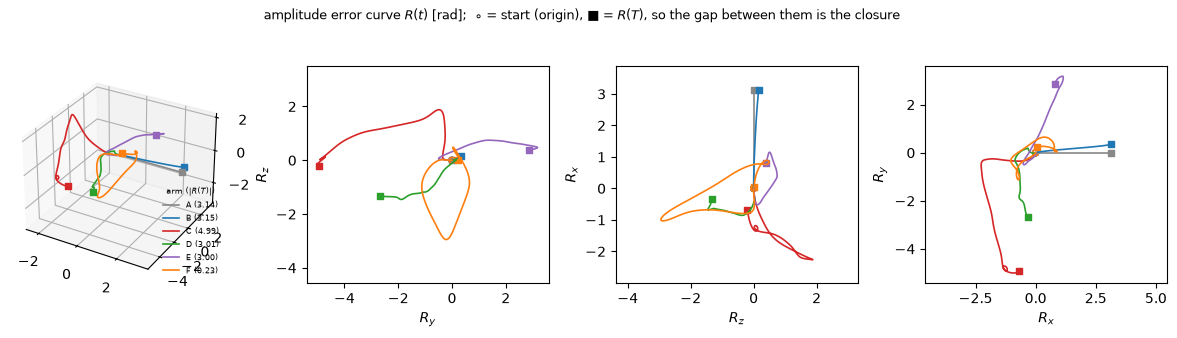

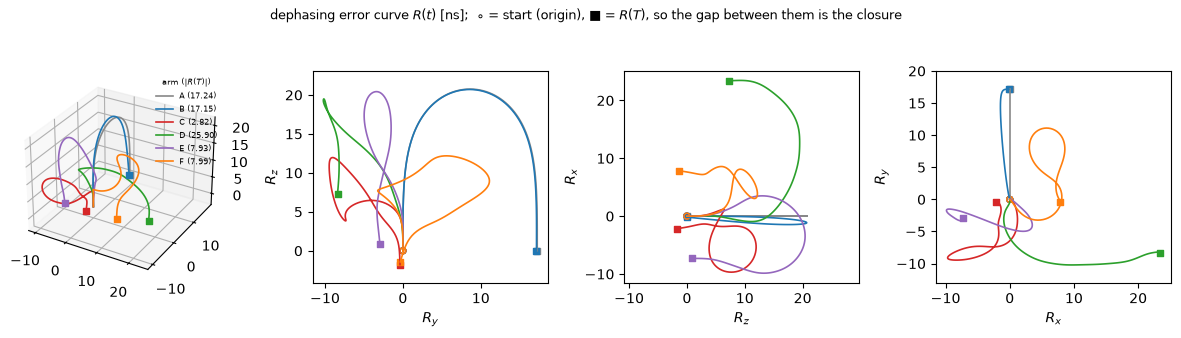

In [4]:
fig = db.plot_error_curves(lab, noise="amplitude")
plt.show()
fig = db.plot_error_curves(lab, noise="dephasing")
plt.show()

## Per-cycle rotation angle: predicted vs. measured

In [5]:
angles = db.print_gate_table(lab, calibrations=cals)

per-cycle rotation error at eps = +3.0% (one cycle = the XX pair)
arm waveform                 |R(T)|    |n.R(T)|   predicted  measured +  measured -     ratio  n to pi/2
--------------------------------------------------------------------------------------------------------
A   Gaussian             3.1416e+00  3.1416e+00  1.8850e-01  1.7985e-01  1.9568e-01      1.04        8.0
B   Gaussian + DRAG      3.1532e+00  3.1299e+00  1.8779e-01  2.0143e-01  1.7475e-01      1.07        7.8
C   Optimized (3D)       4.9857e+00  6.9484e-01  4.1690e-02  3.7362e-04  1.6848e-02      0.40       93.2
D   Opt + fluence cap    3.0077e+00  3.3358e-01  2.0015e-02  1.8430e-02  2.1668e-02      1.08       72.5
E   Opt AD-exact         2.9969e+00  8.2141e-01  4.9285e-02  4.6497e-02  4.2484e-02      0.94       33.8
F   Opt AD-robust        2.3050e-01  5.8661e-02  3.5197e-03  4.4415e-03  6.3108e-03      1.79      248.9
predicted = 2 eps |n . R(T)|, the first-order two-level estimate; only the
component along the

## DB readout: envelope_loss, signal, n@5% -- and Fig. 3, $P_0(n)$

★ This is the figure the whole 1qb-DB bench exists to produce: does the oscillation of
$P_0$ under a deliberate amplitude error get slower once the waveform is optimized? The
**grey dashed line is the $\epsilon=0$ reference run** (same sequence, no injected
amplitude error) -- read the coloured curves *against* it, not as absolute values; on a
transmon the reference is not flat (README §3 point 3).

DB readout after 60 XX cycles (120 gates, 6.00 us) at eps = +-3%
arm waveform             envelope loss  signal at N   max signal    n@5%   Delta P0      P2(N)
----------------------------------------------------------------------------------------------
A   Gaussian                 1.590e-01    4.951e-01    9.491e-01       3  9.775e-01   1.23e-04
B   Gaussian + DRAG          1.571e-01    4.818e-01    9.509e-01       3  9.791e-01   1.13e-04
C   Optimized (3D)           8.638e-02    2.155e-01    2.155e-01      27  3.019e-01   2.02e-03
D   Opt + fluence cap        5.845e-01    4.343e-01    4.343e-01      11  9.286e-01   2.13e-04
E   Opt AD-exact             1.463e-01    7.760e-01    7.965e-01       9  9.287e-01   2.46e-04
F   Opt AD-robust            8.719e-02    1.529e-02    1.529e-02       -  7.197e-02   1.01e-03

Full error model in every column -- no term is ever switched off.
envelope loss = 1 - P0(N) of the eps = 0 reference run;
signal at N   = |P0(N,+-eps) - P0(N,0)|, the discrim

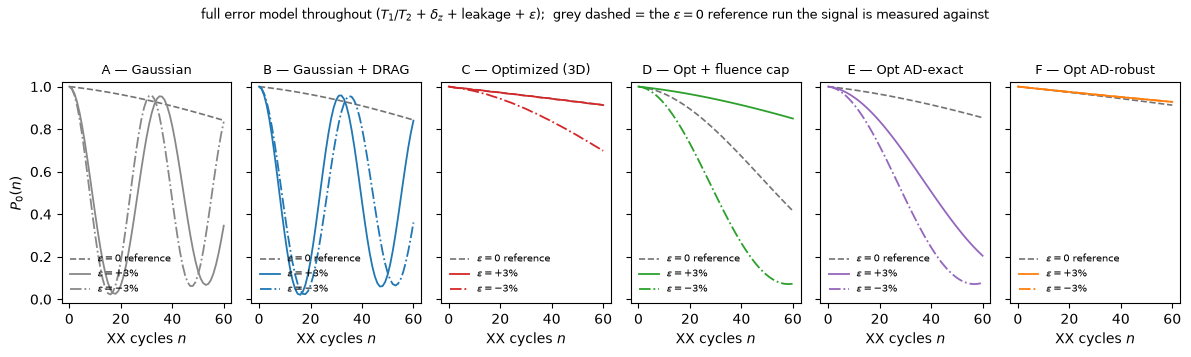

In [6]:
traces = db.db_traces(lab, cycles=db.N_CYCLES, eps=db.TEST_EPS, calibrations=cals)
readouts = db.print_db_table(lab, traces)
fig = db.plot_db_traces(lab, traces)
plt.show()

## 41-point drive-frequency scan (Fig. 4)

scan has 41 points over [-0.50, +0.50] MHz


drive-frequency scan over -0.50 .. +0.50 MHz in 41 steps (60 XX cycles, full model)
arm waveform             P0 nominal   df to P0<0.5  signal nom.  signal min  signal max
---------------------------------------------------------------------------------------
A   Gaussian                 0.8410        > range       0.9491      0.9434      0.9528
B   Gaussian + DRAG          0.8429      0.425 MHz       0.9509      0.9192      0.9554
C   Optimized (3D)           0.9136        > range       0.2155      0.0634      0.2330
D   Opt + fluence cap        0.4155     at nominal       0.4343      0.3047      0.6734
E   Opt AD-exact             0.8537      0.175 MHz       0.7965      0.5733      0.8692
F   Opt AD-robust            0.9128      0.450 MHz       0.0153      0.0058      0.2480

P0 nominal     = P0(N) of the eps = 0 reference at the nominal drive frequency;
df to P0<0.5   = how far the drive may be detuned before the reference falls below 0.5
                 ('> range' = never, within 

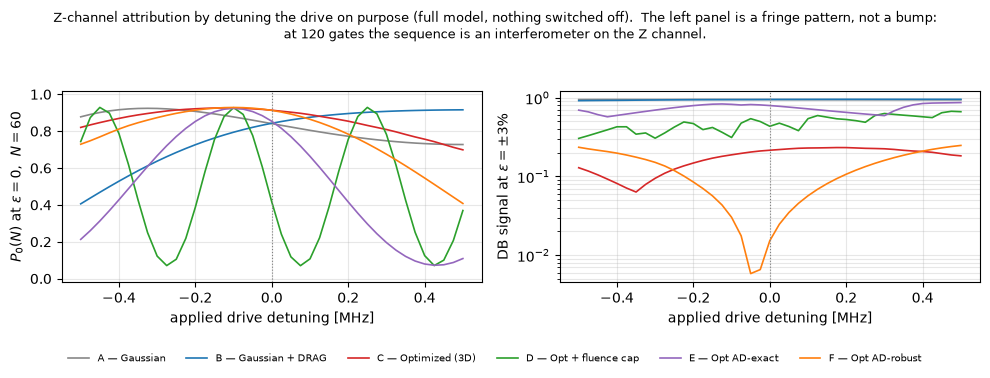

In [7]:
print(f"scan has {len(db.DETUNING_SCAN_MHZ)} points over "
      f"[{db.DETUNING_SCAN_MHZ.min():+.2f}, {db.DETUNING_SCAN_MHZ.max():+.2f}] MHz")
scan = db.print_detuning_scan(lab, cycles=db.N_CYCLES, eps=db.TEST_EPS, calibrations=cals)
fig = db.plot_detuning_scan(lab, scan)
plt.show()

## Fig. 5 — signal vs. injected $\epsilon$

Log axis; ★ negative $\epsilon$ values are kept (not folded onto $|\epsilon|$) -- $C_3$ is
even in $\epsilon$ to leading order, so any $\pm\epsilon$ asymmetry reads out the odd
higher-order channel (README §3 point 5).

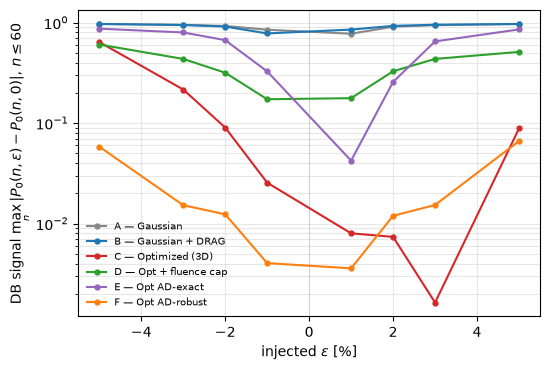

In [8]:
eps_scan = db.signal_vs_epsilon(lab, calibrations=cals)
fig = db.plot_signal_vs_epsilon(lab, eps_scan)
plt.show()

## Numerical checks

In [9]:
checks = db.run_all_checks(lab, cals)

[PASS] coherent_limit
        {'max_abs_diff': {'A': 8.32667803095122e-15, 'B': 4.840623314759461e-15, 'C': 5.329565321918581e-15, 'D': 4.185113772197272e-15, 'E': 7.54965826421603e-15, 'F': 5.4690363164692346e-15}, 'pass': True, 'tol': 1e-10}
[PASS] expm_backends
        {'max_abs_diff': {'A': 2.715511106784476e-15, 'B': 3.831878116016778e-15, 'C': 4.329930803699308e-15, 'D': 2.9790409838967277e-15, 'E': 2.5562612251537557e-15, 'F': 3.216295216128756e-15}, 'pass': True, 'tol': 1e-12}
[PASS] sequence_composition
        {'cycles': 3, 'rows': {'A': {'p0_matrix_power': 0.9956176351837854, 'p0_concatenated': 0.9956176351837819, 'abs_diff': 3.552713678800501e-15}, 'B': {'p0_matrix_power': 0.9956515009686515, 'p0_concatenated': 0.9956515009686636, 'abs_diff': 1.2101430968414206e-14}, 'C': {'p0_matrix_power': 0.9947386477902296, 'p0_concatenated': 0.9947386477902331, 'abs_diff': 3.552713678800501e-15}, 'D': {'p0_matrix_power': 0.994161799067487, 'p0_concatenated': 0.9941617990674894, 'abs_di

## What this says

* **Fig. 1 / calibration** -- what each arm plays and how little a lab calibration has
  left to correct once the virtual $Z$ is set (`frame_phase_minus_phi_vz` in Table 1
  above).
* **Fig. 2 / axial closure table** -- which channel (amplitude or the quasi-static $Z$)
  each arm's DB trace is actually reporting on at this device's noise levels
  (`z_over_amp` column of the axial table above).
* **Fig. 3 / DB readout** -- `envelope_loss` is the $\epsilon=0$ decoherence floor of the
  60-cycle sequence; it is *higher* on this chip than in the default-device X($\pi$) study
  because $T_1=35\,\mu s$ makes $60$ cycles ($6\,\mu s$) $T_1/5.8$ rather than the default
  device's $T_1/10$ at the same cycle count -- reported above rather than compensated by
  quietly shortening the sequence.
* **Fig. 4 / 41-point detuning scan** -- a fringe pattern, not a single bump; `df to P0<0.5`
  says how far each arm's Z-channel sensitivity lets the drive frequency wander before
  the reference itself collapses.
* **Fig. 5 / signal vs. epsilon** -- the same $\max_n$ discriminator as Table 5's `max
  signal` column, now as a curve over $\epsilon\in[-5\%,+5\%]$ instead of one point.
* **Numerical checks** -- independent cross-checks of the coherent/dissipative
  propagation on this device (matrix-power vs. concatenated product, jax vs. QuTiP,
  Liouvillian batching); all should read `PASS`.

★ **Directly answering "does the oscillation get slower once the control is optimized?"
-- Fig. 3, in numbers.** Read off Table 4's `n to pi/2` (how many XX cycles the
*predicted* per-cycle rotation error needs to accumulate to $\pi/2$, i.e. the
oscillation's period) and Table 5's `Delta P0` (the raw 60-cycle peak-to-peak swing of
$P_0$) for arm F and arm E against arm B, on **this** device, next to the default-device
numbers the same two arms gave in `proposals/1qb-DB/notebook.ipynb`:

| | `n to pi/2` (period, cycles) | ratio vs B | `Delta P0` (60-cycle swing) |
|---|---|---|---|
| B, Novera | 7.8 | 1.0x | 0.979 |
| **F, Novera** | **248.9** | **31.9x slower** | **0.072** |
| F, default device | 235.7 | 30.2x slower | 0.085 |
| **E, Novera** | **33.8** | **4.3x slower** | **0.929** |
| E, default device | 62.6 | 8.0x slower | 0.951 |

**Arm F's answer does not change on this chip**: the oscillation is ~32x slower than arm
B here, against ~30x on the default device -- if anything very slightly larger, not
smaller. **Arm E's answer does get worse here**: its oscillation-slowdown advantage over
B roughly halves, from ~8.0x on the default device to ~4.3x on Novera, and its 60-cycle
swing (0.929) is close enough to B's (0.979) that Fig. 3's E panel and B panel look far
more alike on this chip than they do in the default-device notebook. Reported as measured,
not smoothed over: which arm you'd actually want on Novera depends on whether the
deployment cares about the worst-case amplitude-error oscillation (favours F) or the
zero-noise single-gate number (favours E, per Table 1 in `notebook_Xpi.ipynb`) -- the two
questions have different answers on this chip, same as the single-gate/DB split in §7 of
`notebook_Xpi.ipynb`.